<a href="https://colab.research.google.com/github/NicholasAtt/AmazonPrisma/blob/main/notebooks/sentence_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup and Data Loading

This section handles the setup of our working environment. We install all the necessary libraries for text processing, machine learning, and data visualization. We then import these libraries and connect to Google Drive to load the dataset. A small sample of the data is taken to speed up processing for this demonstration.

In [ ]:
print("Installing necessary libraries...")

# Install libraries for NLP, ML and Visualization
!pip install pandas numpy torch scikit-learn --quiet
!pip install sentence-transformers --quiet
!pip install umap-learn hdbscan plotly wordcloud seaborn --quiet

print("Libraries installed.")

Installing necessary libraries...
Libraries installed.


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import re
import time
import os
import gc
from collections import Counter
import warnings

import torch
from sentence_transformers import SentenceTransformer, util

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import umap
import hdbscan

import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive, auth
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from oauth2client.client import GoogleCredentials


# Configurations
warnings.filterwarnings('ignore')
pd.options.display.max_colwidth = 200

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive_service = GoogleDrive(gauth)

id_train = '1kddgLOIVkn5HJw8Ib6rrUh5RkcMwsWeM'
file1 = drive_service.CreateFile({'id': id_train})
file1.GetContentFile('train.csv.gz')
df_train = pd.read_csv('train.csv.gz', header=None, names=['polarity', 'title', 'text'])

## 2. Text Preprocessing and Embeddings

This section focuses on preparing the data. A **`preprocess_text`** function is defined to clean and normalize the review text. The `title` and `text` columns are combined into a single `combined_text` column, which is then used to create **sentence embeddings** with a pre-trained Sentence-Transformer model. These embeddings are dense vector representations that capture the semantic meaning of the text.

In [ ]:
SAMPLE_SIZE = 10000
df = df_train.sample(n=SAMPLE_SIZE, random_state=42)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

# Combine and clean the text
df['combined_text'] = df['title'].apply(preprocess_text) + ". " + df['text'].apply(preprocess_text)
df.dropna(subset=['combined_text'], inplace=True)
df = df[df['combined_text'].str.len() > 20].reset_index(drop=True)

# Normalize the 'polarity' column
if 'polarity' in df.columns and df['polarity'].min() == 1 and df['polarity'].max() == 2:
    print("Normalizing 'polarity' from (1, 2) to (0=Negative, 1=Positive).")
    df['polarity'] = df['polarity'] - 1
    df['sentiment_label'] = df['polarity'].apply(lambda x: 'Positive' if x == 1 else 'Negative')
print(f"Remaining records after cleaning: {len(df)}")

Normalizing 'polarity' from (1, 2) to (0=Negative, 1=Positive).
Remaining records after cleaning: 10000


In [ ]:
print("Loading Sentence Transformer model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
print(f"Model loaded on '{device}'.")

print("Creating text embeddings (this may take some time)...")
start_time = time.time()
texts_to_process = df['combined_text'].tolist()
full_text_embeddings = sbert_model.encode(
    texts_to_process,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Final Vector Shape: {full_text_embeddings.shape}")

Loading Sentence Transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded on 'cpu'.
Creating text embeddings (this may take some time)...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Final Vector Shape: (10000, 384)


## 3. Clustering and Topic Analysis

This section implements **topic modeling** using a two-step clustering approach:

1.  **Dimensionality Reduction**: **UMAP** is used to reduce the high-dimensional embeddings to a 2D space, which makes clustering more efficient and allows for visual representation.
2.  **Clustering**: **HDBSCAN** is applied to the 2D embeddings to identify dense regions of data, forming clusters that represent distinct topics. HDBSCAN is particularly useful as it can handle varying cluster densities and identifies noise points (labeled as -1).

Finally, **c-TF-IDF** (class-based Term Frequency-Inverse Document Frequency) is used to extract the most representative keywords for each topic, providing a clear summary of what each cluster is about.

In [ ]:
# umap + hdbscan clustering
print("Initializing clustering pipeline...")
print("Dimensionality reduction with UMAP...")
umap_reducer = umap.UMAP(
    n_neighbors=40,
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
embedding_2d = umap_reducer.fit_transform(full_text_embeddings)
df['x'] = embedding_2d[:, 0]
df['y'] = embedding_2d[:, 1]

print("Performing clustering with HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    gen_min_span_tree=True
)
clusterer.fit(embedding_2d)
df['cluster_label'] = clusterer.labels_

n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
noise_points = np.sum(clusterer.labels_ == -1)
print(f"Clustering complete: {n_clusters} clusters and {noise_points} noise points.")

print("Creating interactive cluster visualization...")
df_clustered = df[df['cluster_label'] != -1].copy()
df_clustered['combined_text_short'] = df_clustered['combined_text'].str.slice(0, 80) + '...'

fig = px.scatter(
    df_clustered,
    x='x',
    y='y',
    color=df_clustered['cluster_label'].astype(str),
    hover_data={'combined_text_short': True, 'x': False, 'y': False},
    title=f"Topic Clusters ({df_clustered['cluster_label'].nunique()} Clusters)"
)

fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.update_layout(xaxis_title="UMAP 1", yaxis_title="UMAP 2", legend_title_text='Cluster')
fig.show()

Initializing clustering pipeline...
Dimensionality reduction with UMAP...
Performing clustering with HDBSCAN...
Clustering complete: 61 clusters and 1219 noise points.
Creating interactive cluster visualization...


In [ ]:
# advanced topic analysis with c-TF-IDF
print("Topic Analysis of Clusters with c-TF-IDF...")

def c_tf_idf(documents, m, ngram_range=(1, 1)):
    """Calculates c-TF-IDF scores"""
    count = CountVectorizer(ngram_range=ngram_range, stop_words="english").fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

# Extract documents for each cluster
docs_per_topic = df.groupby(['cluster_label'], as_index=False).agg({'combined_text': ' '.join})
docs_per_topic = docs_per_topic[docs_per_topic['cluster_label'] != -1]

# Calculate c-TF-IDF
tf_idf, count = c_tf_idf(docs_per_topic['combined_text'].values, m=len(df))

# Extract keywords for each topic
words = count.get_feature_names_out()
labels = list(docs_per_topic.cluster_label)
tf_idf_transposed = tf_idf.T
indices = tf_idf_transposed.argsort()[:, -10:] # Top 10 words
top_words_per_topic = {label: [words[j] for j in indices[i]][::-1] for i, label in enumerate(labels)}

# Create summary table
cluster_summary = df_clustered.groupby('cluster_label').agg(
    num_reviews=('cluster_label', 'size'),
    avg_sentiment=('polarity', 'mean')
).reset_index()

cluster_summary['main_topics'] = cluster_summary['cluster_label'].apply(lambda x: ', '.join(top_words_per_topic.get(x, ["N/A"])))
cluster_summary = cluster_summary.sort_values(by='num_reviews', ascending=False)

print("Cluster Summary Table (with c-TF-IDF):")
display(cluster_summary.head(50))

Topic Analysis of Clusters with c-TF-IDF...
Cluster Summary Table (with c-TF-IDF):


,cluster_label,num_reviews,avg_sentiment,main_topics
4,4,3000,0.533333,"book, read, books, reading, story, author, written, good, characters, like"
0,0,1493,0.634293,"album, cd, music, songs, song, like, band, sound, best, great"
3,3,1410,0.458156,"movie, film, dvd, movies, watch, acting, great, just, good, funny"
35,35,208,0.552885,"toy, old, daughter, son, seat, fun, toys, baby, loves, kids"
6,6,180,0.550000,"game, games, graphics, play, fun, gameplay, playing, played, like, really"
50,50,124,0.435484,"pan, oven, use, toaster, used, nonstick, stainless, pans, handle, dishwasher"
19,19,114,0.298246,"drive, product, computer, card, software, mac, windows, files, usb, gb"
12,12,103,0.563107,"taste, product, tea, vitamins, vitamin, organic, soup, taking, food, flavor"
2,2,103,0.631068,"workout, yoga, dvd, pilates, video, exercises, exercise, moves, body, dance"
49,49,102,0.441176,"jeans, fit, diapers, bed, soft, pad, size, sheets, pants, material"


## 4. Sentiment and Cluster Analysis

This section explores the relationship between the identified semantic clusters and the sentiment polarity of the reviews. By visualizing the sentiment distribution within the largest clusters using a violin plot, we can see if certain topics are naturally associated with positive or negative opinions. For instance, a cluster about "battery issues" is likely to have a predominantly negative sentiment.

Analyzing the relationship between Sentiment and Semantics (Clusters)...


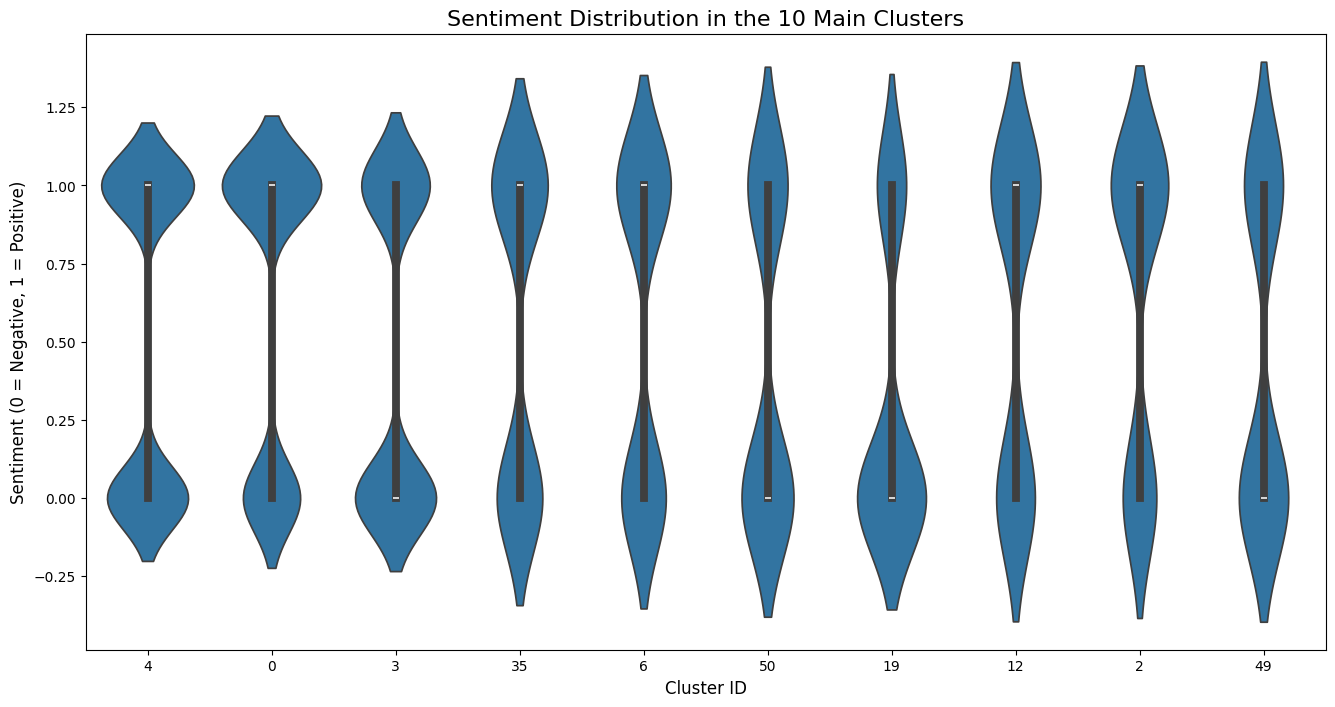

In [ ]:
# sentiment and cluster relationship analysis
print("Analyzing the relationship between Sentiment and Semantics (Clusters)...")

# We select the 10 largest clusters for a clean visualization
top_clusters = cluster_summary.head(10)['cluster_label'].tolist()
df_top_clusters = df[df['cluster_label'].isin(top_clusters)]

plt.figure(figsize=(16, 8))
sns.violinplot(
    data=df_top_clusters,
    x='cluster_label',
    y='polarity',
    order=top_clusters
)
plt.title('Sentiment Distribution in the 10 Main Clusters', fontsize=16)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Sentiment (0 = Negative, 1 = Positive)', fontsize=12)
plt.show()

## 5. Semantic Search System

Here we build a **semantic search system**. Unlike keyword search, this system uses the embeddings to find reviews that are *semantically similar* to a given query. This means it can find relevant results even if the exact words are not present in the reviews. The function `find_similar_reviews` takes a query, encodes it into an embedding, and then computes the cosine similarity against all document embeddings to find the most relevant ones.

In [ ]:
# semantic search system
print("Semantic Search System")

def find_similar_reviews(query, model, embeddings, df, top_k=5):
    """
    Finds the most similar reviews to a given query.
    """
    print(f"Searching for query: '{query}'")
    start_time = time.time()

    # Encode the query
    query_embedding = model.encode(query, convert_to_tensor=True)

    # Calculate cosine similarity
    # The util.cos_sim function is optimized
    cosine_scores = util.cos_sim(query_embedding, embeddings)[0]

    # Find the indices of the top_k most similar reviews
    top_results = torch.topk(cosine_scores, k=top_k)

    end_time = time.time()
    print(f"Search completed in {end_time - start_time:.4f} seconds.\n")

    # Prepare the result
    results_df = df.iloc[top_results[1].cpu().numpy()].copy()
    results_df['similarity_score'] = [score.item() for score in top_results[0].cpu().numpy()]

    return results_df[['similarity_score', 'combined_text', 'cluster_label', 'sentiment_label']]

full_text_embeddings_tensor = torch.tensor(full_text_embeddings).to(device)

# --- Example 1: Searching for a specific problem ---
query1 = "the battery life is terrible"
similar_reviews_1 = find_similar_reviews(query1, sbert_model, full_text_embeddings_tensor, df, top_k=5)
print("Results for a problem (battery):")
display(similar_reviews_1)

# --- Example 2: Searching for a positive feature ---
query2 = "amazing camera and photos"
similar_reviews_2 = find_similar_reviews(query2, sbert_model, full_text_embeddings_tensor, df, top_k=5)
print("\nResults for a positive feature (camera):")
display(similar_reviews_2)

# --- Example 3: Searching for an abstract concept ---
query3 = "good value for the money"
similar_reviews_3 = find_similar_reviews(query3, sbert_model, full_text_embeddings_tensor, df, top_k=5)
print("\nResults for a concept (value for money):")
display(similar_reviews_3)

# Final memory cleanup
del full_text_embeddings, full_text_embeddings_tensor, embedding_2d
gc.collect()

Semantic Search System
Searching for query: 'the battery life is terrible'
Search completed in 0.0593 seconds.

Results for a problem (battery):


,similarity_score,combined_text,cluster_label,sentiment_label
9782,0.585082,battery calamity. batteries are terrible ..lucky to get 5 minutes use per battery after first few uses..beware!,26,Negative
5880,0.490458,not impressed. this unit has several nice features however i was not impressed with the battery life. i spent about 2 12 hours learning how to use and loading this unit. the next day after playing...,-1,Negative
1143,0.488019,"not very good...if you need a really good phone.. this is a really bad phone. my battery door falls off all the time, and then the battery falls out! also, my phone just shuts down by itself. ive ...",22,Negative
9068,0.487268,what a complete waste!!!!!. on one phone i can talk for an hour and a half and the other for an hour before it goes dead. i must place it back on the charger after every use or i will not have a p...,22,Negative
8374,0.481219,"short battery life!. the phone is great, when it comes to looks. it is slim and lightweight, but the battery life is so short! you have to charge it every other day, if you dont use it at all. if ...",22,Negative


Searching for query: 'amazing camera and photos'
Search completed in 0.0248 seconds.


Results for a positive feature (camera):


,similarity_score,combined_text,cluster_label,sentiment_label
5604,0.640640,pretty impressed. brought a few of these for a family beach trip. had a couple of them developed at cvs with no problem just had them ripped to a cd and loaded them onto my computer. i really like...,43,Positive
5832,0.629339,so great!. this is my first digital camera and i love it! its small and very easy to use. theres plenty of advanced features to add effects on the computer and different modes which are a lot of f...,44,Positive
6516,0.579350,good throw away camera. camera works good the first day after that pictures dark and blury lcd screen works when it wants to would not reccomend purchasing!!!!,44,Negative
5408,0.572644,photomax. i took some pics today they were clear and perfect i like this camera alot and i bought it from amazon in 2000 and it has a great look,44,Positive
4404,0.553198,"probably the best camera for this price and quite a bit more, too. god, this is a wonderful camera. its small, its light, and its got a genuine wide angle lens. you can still together shots for a ...",44,Positive


Searching for query: 'good value for the money'
Search completed in 0.0268 seconds.


Results for a concept (value for money):


,similarity_score,combined_text,cluster_label,sentiment_label
6665,0.575079,"value for money, definately!. an excellent camcorder!! i have nothing bad to say about its performance, although an lcd sacreen would have been convenient.",44,Positive
4018,0.504719,"perfect for the price.. i bought them because you cannot beat the price. i figured i could get a minimum of a year out them. have used them a couple of times and i am impressed, sure they are chea...",54,Positive
6057,0.497818,worth the money. this item is definately worth the price.the quality is great and it amazingly increased my night time capabilities. although the light enhancement isnt that important and as great...,-1,Positive
5053,0.487092,"it was a good deal for the book. it was a good deal for the book, but the print on the pages was tiny and it hurt my eyes to read. oops but i heard the book was great",4,Positive
8179,0.473776,"excellent value.. when the battery that came with my canon camera stopped holding a charge, i was torn with spending a big chunk of change on a new canon battery or just shopping for a new camera ...",-1,Positive


21847

## 6. Detailed Cluster Inspection

This section provides a deeper dive into individual clusters. The `inspect_cluster` function is used to display key statistics for a given cluster, including the number of reviews, average sentiment, and top keywords. This allows for a qualitative analysis of the topics identified by the clustering algorithm and helps validate the results. Examples for both positive and negative clusters are provided.

In [ ]:
# cluster analysis

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def inspect_cluster(cluster_id, df_reviews, df_summary, top_n_reviews=3):
    """
    Provides a detailed analysis of a single cluster.

    Args:
        cluster_id (int): The ID of the cluster to inspect.
        df_reviews (pd.DataFrame): The main DataFrame with reviews and cluster labels.
        df_summary (pd.DataFrame): The summary DataFrame with topics per cluster.
        top_n_reviews (int): The number of example reviews to show.
    """
    if cluster_id not in df_summary['cluster_label'].values:
        print(f"Cluster {cluster_id} not found in the summary.")
        return

    # Retrieve general information
    cluster_info = df_summary[df_summary['cluster_label'] == cluster_id].iloc[0]
    num_reviews = cluster_info['num_reviews']
    avg_sentiment = cluster_info['avg_sentiment']
    main_topics = cluster_info['main_topics']

    print(f"\nAnalysis of Cluster {cluster_id}")
    print(f"   - Number of Reviews: {num_reviews}")
    print(f"   - Average Sentiment: {avg_sentiment:.2f} (0=Negative, 1=Positive)")
    print(f"   - Main Topics (c-TF-IDF): {main_topics}")

    # Show example reviews
    cluster_reviews_df = df_reviews[df_reviews['cluster_label'] == cluster_id]
    print(f"\n Example Reviews (first {top_n_reviews}):")
    for i, review in enumerate(cluster_reviews_df['combined_text'].head(top_n_reviews)):
        print(f"  {i+1}. {review[:250]}...") # Truncate for readability

# Negative Clusters
inspect_cluster(56, df, cluster_summary)
inspect_cluster(12, df, cluster_summary)
inspect_cluster(8, df, cluster_summary)

# Positive Clusters
inspect_cluster(3, df, cluster_summary)
inspect_cluster(21, df, cluster_summary)
inspect_cluster(49, df, cluster_summary)


Analysis of Cluster 56
   - Number of Reviews: 33
   - Average Sentiment: 0.73 (0=Negative, 1=Positive)
   - Main Topics (c-TF-IDF): bag, backpack, large, quality, chair, use, price, earrings, carry, straps

 Example Reviews (first 3):
  1. shimmer bag. i have just received this bag today and i absolutely love it! the color is exactly as it appears on the website! it was the exact color i was looking for and it is beautiful!...
  2. nice earrings from amazon. i bought the earrings for my daughter who adored them. they were small but bright and looked great. we went to view the floats the night before the rose parade and a couple of her friends commented on them. she loves them....
  3. elegant little purse. by starhollypennsylvania asin b000a22cf4 beehive brown eveningparty bag this is an elegant different bag, i like things that are unique. it is a little small, so be sure that is what you wanti love it to go out on special occasi...

Analysis of Cluster 12
   - Number of Reviews: 10

## 7. Title and Text Semantic Similarity Analysis

In this final section, we perform an in-depth analysis of the **semantic coherence** between the title and the main text of each review. The process is as follows:

1.  **Separate Embeddings**: We generate separate embeddings for the `title` and `text` of each review.
2.  **Cosine Similarity**: We calculate the **cosine similarity** between the title and text embeddings to get a numerical score representing their semantic similarity.
3.  **Visualization & Analysis**: We visualize the distribution of these similarity scores to understand the general coherence of the dataset. We also compare the similarity scores for positive and negative reviews to see if there is a correlation between sentiment and coherence.
4.  **Example Inspection**: The reviews with the lowest and highest similarity scores are displayed to provide concrete examples of what high and low coherence looks like.

Starting semantic similarity analysis between Title and Text...
🧬 Creating embeddings for Titles...


Batches:   0%|          | 0/306 [00:00<?, ?it/s]


 Creating embeddings for Texts...


Batches:   0%|          | 0/306 [00:00<?, ?it/s]


 Similarity calculation completed.

 Visualizing the distribution of similarity scores...


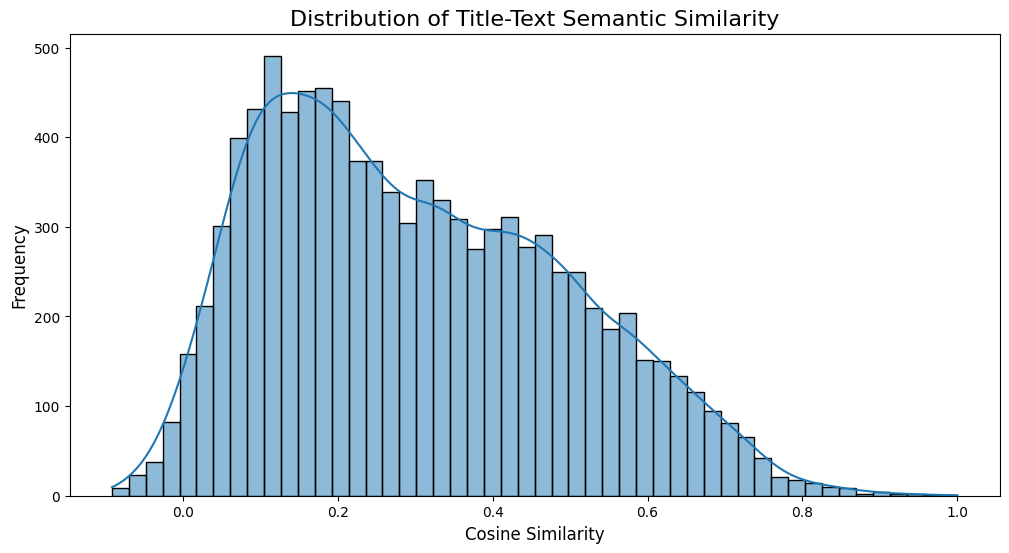


 Analyzing similarity by Sentiment...


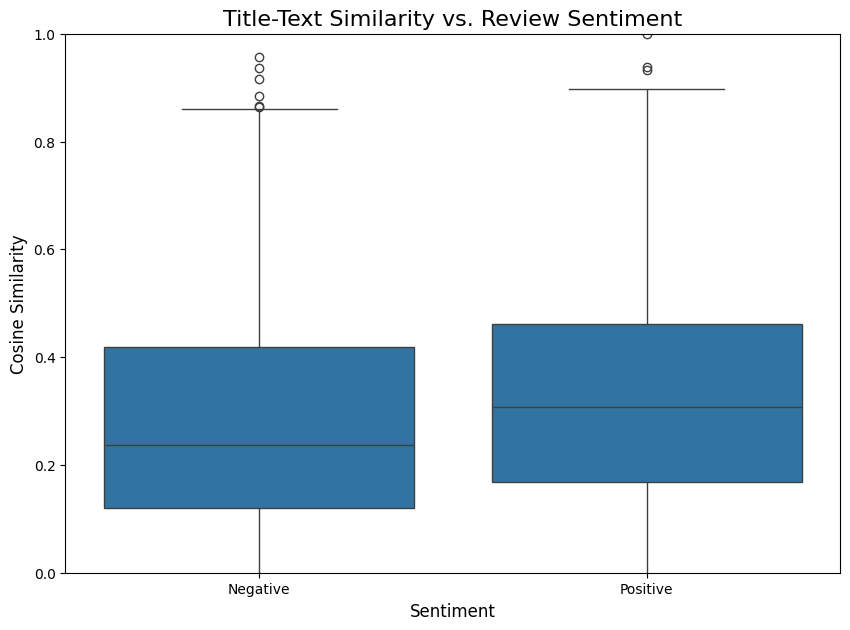


 Average similarity by sentiment:
sentiment_label
Negative    0.277366
Positive    0.323495
Name: title_text_similarity, dtype: float32
--------------------------------------------------

 Examples of reviews with LOW Title-Text coherence (the worst 10):


,title_text_similarity,sentiment_label,title,text
2871,-0.091743,Positive,Right on target yet someting missing,The book had been in the making at Stanford for some time. I happened to use a manuscript of it in 1991 at Virginia Tech. I was pleasantly surprised how quickly a student could pick up relevant as...
6901,-0.088347,Negative,Don't Buy This!!!,The temperature was never quite right (all of my meats were over cooked - and I started taking them out earlier and earlier) and it broke after about 5 uses.
4484,-0.080834,Negative,Waste of Time,"Starting homeschooling my 4, 8 & 6 year olds and was wondering what to teach when they need to learn things and where can I find this information. This book did not contain that information is lis..."
5817,-0.074659,Negative,What a disaster.,I ordered this because of the positive reviews. Nowhere does it indicate that it doesn't work on an Apple. There is some vague notation about what to do if you use an Apple. I spent about an hour ...
6263,-0.073871,Negative,hope hes NOT a comedian at night,"Ok. i know its called ""for dummies"".... and i dint really consider myself one, until i dropped $29.99, but, i looked at the first few chapters, and it look OK.... I thought id get much more ""Windo..."
3708,-0.072907,Negative,I call Bull....,"Highly unlikely premise. No comment given in the book regarding the actual percentage of crystals sampled. Given the potential for thousands of crystals in a drop of water, how many of these were ..."
7544,-0.072537,Positive,very accurate!,"I can use this mouse on any surface what so ever! The mini receiver is so compact, without clutter."
3873,-0.072110,Negative,John Doe,"Unfortunately I am one of those people who crave the release of a new Tom Clancy novel, however, being so few and far between, I have found myself passing time reading non-fiction books and resear..."
8918,-0.071183,Negative,Not as describled,This picture would have made my daughter so happy but unfortunately the product that arrived was Yellow. I would not have ordered this item if I had realized it was not going to be pink as picture...
5406,-0.069182,Positive,Not Microserfs,"Dennis Coupland's Miss Wyoming was not at all what I expected, but it was well worth the wild read. Part social commentary on the cult of celebrity and part gonzo Hollywood buddy book, this is a f..."



 Examples of reviews with HIGH Title-Text coherence (the best 10):


,title_text_similarity,sentiment_label,title,text
1022,1.000000,Positive,Excellent film and transfer...Very pleased with this purchase. It's one of the better films from that period that was overlook.,Excellent film and transfer...Very pleased with this purchase. It's one of the better films from that period that was overlook.
3289,0.957214,Negative,Poor quality. I have 2 and they both malfunction.,"Poor quality. I have 2 and they both malfunction.Nice while it lasts,,,,"
4985,0.938054,Positive,Very good work out for beginners. She is tough but encouraging. Made me keep going even when I didn't want to.,Very good work out for beginners. She is tough but encouraging and kept me working out long after I wanted to stop. It gets harder and harder so as your fitness progresses the workout progresses w...
4875,0.936562,Negative,Case is cracked...hope the CD isn't...,Case is cracked...hope the CD isn't since this is a gift for a family member. We'll find out on Christmas...
7680,0.933307,Positive,This is a good book that introduces the common tesuji.,"This is a good book that introduces the common tesuji. Complete, but a bit lacking in examples."
321,0.916664,Negative,This is not the correct filter for Presto CoolDaddy deep fryer. Here is a link to get the correct filters: [...],This wave-shaped filter is not the correct filter for Presto CoolDaddy deep fryer. The proper filter is a rectangle in shape. Here is info to get the correct filters: You can purchase them through...
5002,0.898223,Positive,It came pretty fast and worked well. Nice.,It came pretty fast and worked well. Nice.It came pretty fast and worked well. Nice.It came pretty fast and worked well. Nice.
2934,0.895239,Positive,Good Introduction to Parallel Programming with MPI,"This book is a great introduction to the theory of parallel programming. It is important to note that it is not a great reference for MPI, but it does a good job introducing the basic MPI function..."
850,0.895162,Positive,Good story line and nice lesson for pre-schoolers!,"Good story line and nice lesson for pre-schoolers! Can remind toddler of the situation, and how Little Foot and his friends handled it."
4936,0.892357,Positive,It was a good deal for the book,"It was a good deal for the book, but the print on the pages was tiny and It hurt my eyes to read. OOPS but I heard the book was great"


In [ ]:
# title and text semantic similarity
print("Starting semantic similarity analysis between Title and Text...")

# Ensure 'title' and 'text' are clean strings
df['title_processed'] = df['title'].apply(preprocess_text)
df['text_processed'] = df['text'].apply(preprocess_text)

# Remove rows where title or text are too short after preprocessing
df.dropna(subset=['title_processed', 'text_processed'], inplace=True)
df = df[df['title_processed'].str.len() > 5].reset_index(drop=True)
df = df[df['text_processed'].str.len() > 10].reset_index(drop=True)

# Create separate embeddings for titles and texts
print("🧬 Creating embeddings for Titles...")
title_embeddings = sbert_model.encode(
    df['title_processed'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\n Creating embeddings for Texts...")
text_embeddings = sbert_model.encode(
    df['text_processed'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

# Calculate cosine similarity (pairwise) efficiently
# Normalize the embeddings (needed for dot product calculation)
title_embeddings_norm = title_embeddings / np.linalg.norm(title_embeddings, axis=1, keepdims=True)
text_embeddings_norm = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)

# Calculate similarity as row-wise dot product
similarity_scores = np.sum(title_embeddings_norm * text_embeddings_norm, axis=1)

df['title_text_similarity'] = similarity_scores
print("\n Similarity calculation completed.")


# Analysis and Visualization
print("\n Visualizing the distribution of similarity scores...")

# General distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df['title_text_similarity'], kde=True, bins=50)
plt.title('Distribution of Title-Text Semantic Similarity', fontsize=16)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

print("\n Analyzing similarity by Sentiment...")
# Box Plot to analyze discrepancy by polarity
plt.figure(figsize=(10, 7))
sns.boxplot(x='sentiment_label', y='title_text_similarity', data=df)
plt.title('Title-Text Similarity vs. Review Sentiment', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Cosine Similarity', fontsize=12)
plt.ylim(0, 1) # Similarity is between -1 and 1, but SBERT tends to give values > 0
plt.show()

# Calculate the mean per group for a numerical analysis
similarity_by_sentiment = df.groupby('sentiment_label')['title_text_similarity'].mean()
print("\n Average similarity by sentiment:")
print(similarity_by_sentiment)
print("-" * 50)


# Inspecting reviews with low coherence
print("\n Examples of reviews with LOW Title-Text coherence (the worst 10):")
low_similarity_reviews = df.sort_values(by='title_text_similarity', ascending=True)
display(low_similarity_reviews[['title_text_similarity', 'sentiment_label', 'title', 'text']].head(50))

print("\n Examples of reviews with HIGH Title-Text coherence (the best 10):")
high_similarity_reviews = df.sort_values(by='title_text_similarity', ascending=False)
display(high_similarity_reviews[['title_text_similarity', 'sentiment_label', 'title', 'text']].head(50))